# Chapter 5: Distribution Shift and Adversarial Robustness

Companion notebook for *Practical AI Safety from First Principles*, Chapter 5.

Chapter 4 left us with a full safety operating point: a fitted classifier, a Platt calibrator, and a threshold selected on held-out data. Everything we measured assumed the future looks like BeaverTails. This notebook breaks that assumption on purpose. We freeze the Chapter 4 model and threshold, then ask what happens when the input distribution moves: casing and punctuation changes, typographical noise, and eventually an adversarial framing of the same question. We build character n-gram and combined word-plus-character classifiers to see whether a different representation is more robust, and we build simple drift signals (PSI, Jensen-Shannon divergence, feature-space distance) that do not require ground-truth labels.

By the end we will have: a frozen clean baseline, reproducible label-preserving shifted test sets, paired evasion analysis, a robustness matrix across models and conditions, per-category robustness, a data-augmentation experiment (and a check for whether it generalizes beyond the exact attack it trained on), calibration-under-shift diagnostics, and unlabeled drift signals extending Chapter 4's allow/review/block policy.

## 5.1-5.3 The assumption we have been leaning on

Every train-test split we have used so far assumes training and test data come from the same distribution, the IID assumption. That is what makes a test score meaningful as evidence about the future. For a deployed system it is more honest to write P_train(x, y) and P_deploy(x, y) as two potentially different distributions and ask whether the difference is large enough to matter, not whether it is exactly zero (it never is).

Three useful categories of shift:

- **Covariate shift**: the input distribution P(x) changes, but P(y given x) stays roughly stable. Users express the same safe/unsafe intent with different vocabulary or formatting.
- **Label shift**: the class prevalence P(y) changes, but the class-conditional inputs P(x given y) stay roughly stable. A benchmark's unsafe rate rarely matches production traffic.
- **Concept drift**: P(y given x) itself changes, the same input now means something different because policy changed, or context shifted.

Text is an especially exposed target: an enormous number of surface forms can express the same intent, ordinary users introduce typos and dialect without any adversarial intent, and once people know a safety classifier exists, some of them adapt to it. That last point makes the input distribution partly endogenous to the classifier itself, unlike a static photo dataset.

## 5.4 Keep the Chapter 4 policy fixed

In [1]:
# We freeze the Chapter 4 model, calibrator and threshold rather than choosing a new operating
# point after seeing shifted data. If any artifact is missing (e.g. this notebook runs on its own
# after a fresh clone), we regenerate it here using the same procedure as the earlier chapters.
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import yaml

DATA_DIR = Path("data/processed")
MODEL_DIR = Path("models")
CONFIG_DIR = Path("config")
REPORTS_DIR = Path("reports")
for d in (DATA_DIR, MODEL_DIR, CONFIG_DIR, REPORTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "beavertails_train.parquet"
TEST_PATH = DATA_DIR / "beavertails_test.parquet"
BASE_MODEL_PATH = MODEL_DIR / "beavertails_tfidf_logreg_ch4.joblib"
CALIBRATOR_PATH = MODEL_DIR / "beavertails_platt_ch4.joblib"
POLICY_PATH = CONFIG_DIR / "beavertails_safety_policy_ch4.yaml"

if TRAIN_PATH.exists() and TEST_PATH.exists():
    train_df = pd.read_parquet(TRAIN_PATH)
    test_df = pd.read_parquet(TEST_PATH)
else:
    print("Processed split not found, regenerating it from BeaverTails (same steps as Chapter 2)...")
    from datasets import load_dataset
    from sklearn.model_selection import train_test_split

    dataset = load_dataset("PKU-Alignment/BeaverTails", split="30k_train")
    df = dataset.to_pandas()
    df["text"] = (
        "[PROMPT]\n" + df["prompt"].fillna("") +
        "\n\n[RESPONSE]\n" + df["response"].fillna("")
    )
    df["target"] = (~df["is_safe"]).astype(int)

    train_df, test_df = train_test_split(
        df[["prompt", "response", "text", "category", "target"]],
        test_size=0.20, stratify=df["target"], random_state=42,
    )
    train_df.to_parquet(TRAIN_PATH, index=False)
    test_df.to_parquet(TEST_PATH, index=False)

print("train:", train_df.shape, "test:", test_df.shape)

Processed split not found, regenerating it from BeaverTails (same steps as Chapter 2)...


train: (21748, 5) test: (5438, 5)


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix

def metrics_at_threshold(y_true, scores, threshold):
    pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    return {"threshold": threshold, "precision": precision, "recall": recall}

def recall_constrained_threshold(y_true, scores, candidate_thresholds, min_recall=0.95):
    rows = pd.DataFrame([metrics_at_threshold(y_true, scores, t) for t in candidate_thresholds])
    feasible = rows[rows["recall"] >= min_recall]
    chosen_row = (feasible if len(feasible) else rows).sort_values("precision", ascending=False).iloc[0]
    return float(chosen_row["threshold"])

if BASE_MODEL_PATH.exists() and CALIBRATOR_PATH.exists() and POLICY_PATH.exists():
    base_clf = joblib.load(BASE_MODEL_PATH)
    calibrator = joblib.load(CALIBRATOR_PATH)
    with open(POLICY_PATH) as f:
        policy = yaml.safe_load(f)
    threshold = policy["policy"].get("block_at_or_above", policy["policy"].get("block_threshold"))
else:
    print("Chapter 4 artifacts not found, regenerating them (same steps as Chapter 4)...")
    fit_df, cal_df = train_test_split(
        train_df, test_size=0.20, stratify=train_df["target"], random_state=42,
    )
    base_clf = Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True, ngram_range=(1, 2), min_df=2,
            max_features=100_000, sublinear_tf=True,
        )),
        ("logreg", LogisticRegression(
            max_iter=1_000, class_weight="balanced", random_state=42,
        )),
    ])
    base_clf.fit(fit_df["text"], fit_df["target"])

    # Threshold is selected on the base model's own (uncalibrated) score, exactly as in Chapter 4,
    # then reused as-is against the calibrated score at evaluation time.
    p_cal_raw = base_clf.predict_proba(cal_df["text"])[:, 1]
    y_cal = cal_df["target"].to_numpy()
    candidate_thresholds = np.linspace(0.05, 0.95, 181)
    threshold = recall_constrained_threshold(y_cal, p_cal_raw, candidate_thresholds, min_recall=0.95)

    s_cal = base_clf.decision_function(cal_df["text"])
    calibrator = LogisticRegression()
    calibrator.fit(s_cal.reshape(-1, 1), y_cal)

    joblib.dump(base_clf, BASE_MODEL_PATH)
    joblib.dump(calibrator, CALIBRATOR_PATH)
    policy = {
        "model": {"path": str(BASE_MODEL_PATH), "version": "chapter4-v1"},
        "calibration": {"method": "platt", "path": str(CALIBRATOR_PATH)},
        "policy": {"unsafe_label": 1, "block_at_or_above": round(threshold, 4)},
        "selection": {"calibration_split_seed": 42, "minimum_unsafe_recall": 0.95},
    }
    with open(POLICY_PATH, "w") as f:
        yaml.safe_dump(policy, f, sort_keys=False)

print("Frozen block threshold:", threshold)

Chapter 4 artifacts not found, regenerating them (same steps as Chapter 4)...


Frozen block threshold: 0.29


## 5.5 Re-establish the clean baseline

Robustness is a comparative statement. Before shifting anything, we reproduce the clean test metrics that everything else will be measured against.

In [3]:
from sklearn.metrics import precision_score, recall_score, f1_score

X_clean = test_df["text"]
y_clean = test_df["target"].to_numpy()

# The calibrator was fit on base_clf's raw linear score (decision_function), not on predict_proba,
# so we have to feed it the same scale here or its output is meaningless.
s_clean = base_clf.decision_function(X_clean)
p_clean = calibrator.predict_proba(s_clean.reshape(-1, 1))[:, 1]
yhat_clean = (p_clean >= threshold).astype(int)

def safety_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "false_positive_rate": fp / (fp + tn),
        "false_negative_rate": fn / (fn + tp),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
    }

clean_metrics = safety_metrics(y_clean, yhat_clean)
clean_metrics

{'precision': 0.7281479604763111,
 'recall': 0.9220404234841193,
 'f1': 0.8137032842582106,
 'false_positive_rate': np.float64(0.46230073244291253),
 'false_negative_rate': np.float64(0.07795957651588066),
 'tp': 2874,
 'fp': 1073,
 'tn': 1248,
 'fn': 243}

In [4]:
import json

with open(REPORTS_DIR / "ch5_clean_baseline.json", "w") as f:
    json.dump(clean_metrics, f, indent=2)

## 5.6-5.7 Build shifted test sets, not randomly corrupted training data

We are evaluating, not (yet) retraining. Every shifted copy of the test set keeps the original text, the original label, and the shift name, so failures stay traceable back to a clean example. We start deliberately mild: casing and punctuation. Because the Chapter 3/4 vectorisers use `lowercase=True`, casing is a negative control, we expect almost no effect. Punctuation removal can matter more because punctuation participates in tokenisation and bigram formation.

In [5]:
def lower_case(text):
    return text.lower()

def remove_punctuation(text):
    table = str.maketrans("", "", "!?.,;:'\"")
    return text.translate(table)

def make_shifted_copy(df, transform, name):
    out = df.copy()
    out["text_clean"] = out["text"]
    out["text"] = out["text"].map(transform)
    out["shift_type"] = name
    return out

lower_df = make_shifted_copy(test_df, lower_case, "lowercase")
punct_df = make_shifted_copy(test_df, remove_punctuation, "remove_punctuation")

In [6]:
def evaluate_shifted(df):
    s_raw = base_clf.decision_function(df["text"])
    p = calibrator.predict_proba(s_raw.reshape(-1, 1))[:, 1]
    yhat = (p >= threshold).astype(int)
    return safety_metrics(df["target"].to_numpy(), yhat), p, yhat

lower_metrics, p_lower, yhat_lower = evaluate_shifted(lower_df)
punct_metrics, p_punct, yhat_punct = evaluate_shifted(punct_df)

print("lowercase:", lower_metrics)
print("remove_punctuation:", punct_metrics)

lowercase: {'precision': 0.7281479604763111, 'recall': 0.9220404234841193, 'f1': 0.8137032842582106, 'false_positive_rate': np.float64(0.46230073244291253), 'false_negative_rate': np.float64(0.07795957651588066), 'tp': 2874, 'fp': 1073, 'tn': 1248, 'fn': 243}
remove_punctuation: {'precision': 0.7251256281407035, 'recall': 0.9258902791145333, 'f1': 0.813301394955615, 'false_positive_rate': np.float64(0.4713485566566135), 'false_negative_rate': np.float64(0.0741097208854668), 'tp': 2886, 'fp': 1094, 'tn': 1227, 'fn': 231}


If lowercasing changes performance materially, something is wrong with our assumptions or implementation, the vectoriser already normalises case. A good robustness suite includes transformations the model should pass comfortably as well as ones that challenge it.

## 5.8 Controlled typographical noise

Ordinary production text has typos. We build a reproducible transformation that swaps adjacent alphabetic characters with small probability, seeded per row (derived from the row index) so the perturbation is deterministic without every row sharing the exact same pseudo-random sequence.

In [7]:
import random

def swap_adjacent_chars(text, p=0.03, seed=42):
    rng = random.Random(seed)
    chars = list(text)
    i = 0
    while i < len(chars) - 1:
        if chars[i].isalpha() and chars[i + 1].isalpha() and rng.random() < p:
            chars[i], chars[i + 1] = chars[i + 1], chars[i]
            i += 2
        else:
            i += 1
    return "".join(chars)

def typo_shift_row(row, base_seed=42):
    row_seed = base_seed + int(row.name)
    return swap_adjacent_chars(row["text"], p=0.03, seed=row_seed)

typo_df = test_df.reset_index(drop=True).copy()
typo_df["text_clean"] = typo_df["text"]
typo_df["text"] = typo_df.apply(typo_shift_row, axis=1)
typo_df["shift_type"] = "adjacent_typo_3pct"

typo_metrics, p_typo, yhat_typo = evaluate_shifted(typo_df)
print(typo_metrics)

{'precision': 0.7184538653366583, 'recall': 0.9242861726018607, 'f1': 0.8084748140872737, 'false_positive_rate': np.float64(0.4864282636794485), 'false_negative_rate': np.float64(0.07571382739813924), 'tp': 2881, 'fp': 1129, 'tn': 1192, 'fn': 236}


A word-level TF-IDF model can be surprisingly sensitive here: a single swapped letter turns a known token into an out-of-vocabulary one. Character n-grams (section 5.18) should be less sensitive, since most local character sequences survive the perturbation.

## 5.9 Do not assume the label survives every transformation

We are reusing the original label y for every transformed input x'. That is only valid if the transformation preserves the property being labelled, effectively assuming P(y given x') is about equal to P(y given x) for every shift in the suite. Lowercasing and mild punctuation removal almost certainly preserve meaning. A small typo rate usually does too, but the more aggressive a transformation gets, the less comfortable we should be carrying the original label forward automatically. A real robustness dataset needs a sampled manual review of each shift family, not just an automated pipeline.

## 5.10 Measuring degradation rather than reporting another score

A shifted recall of 0.82 is meaningless on its own. It matters relative to the clean recall it is being compared against.

In [8]:
rows = []
for name, metrics in [
    ("clean", clean_metrics),
    ("lowercase", lower_metrics),
    ("remove_punctuation", punct_metrics),
    ("adjacent_typo_3pct", typo_metrics),
]:
    rows.append({"shift": name, **metrics})

robustness_table = pd.DataFrame(rows)

for metric in ["precision", "recall", "f1"]:
    clean_value = robustness_table.loc[robustness_table["shift"] == "clean", metric].iloc[0]
    robustness_table[f"delta_{metric}"] = robustness_table[metric] - clean_value

robustness_table

,shift,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn,delta_precision,delta_recall,delta_f1
0,clean,0.728148,0.922040,0.813703,0.462301,0.077960,2874,1073,1248,243,0.000000,0.000000,0.000000
1,lowercase,0.728148,0.922040,0.813703,0.462301,0.077960,2874,1073,1248,243,0.000000,0.000000,0.000000
2,remove_punctuation,0.725126,0.925890,0.813301,0.471349,0.074110,2886,1094,1227,231,-0.003022,0.003850,-0.000402
3,adjacent_typo_3pct,0.718454,0.924286,0.808475,0.486428,0.075714,2881,1129,1192,236,-0.009694,0.002246,-0.005228


A model that wins by one point of clean F1 but loses fifteen points under mild shift may not be the model to deploy. We will build a fuller version of this table once we have more than one model to compare (section 5.21).

## 5.11 Pairwise failure analysis

Aggregate degradation tells us how much changed. Pairing every shifted example with its clean counterpart tells us which examples flipped, and lets us define an **evasion success rate** among unsafe examples the clean model originally caught.

In [9]:
clean_pred = yhat_clean
shift_pred = yhat_typo
y = y_clean

clean_detected_unsafe = (y == 1) & (clean_pred == 1)
shift_evaded = clean_detected_unsafe & (shift_pred == 0)

esr = shift_evaded.sum() / clean_detected_unsafe.sum()
print(f"Evasion success rate (typo shift): {esr:.3f}")

Evasion success rate (typo shift): 0.010


In [10]:
paired = pd.DataFrame({
    "clean_text": test_df["text"].reset_index(drop=True),
    "shifted_text": typo_df["text"],
    "target": y,
    "p_clean": p_clean,
    "p_shift": p_typo,
    "pred_clean": clean_pred,
    "pred_shift": shift_pred,
})

failures = paired[
    (paired["target"] == 1) & (paired["pred_clean"] == 1) & (paired["pred_shift"] == 0)
].copy()
failures["score_drop"] = failures["p_shift"] - failures["p_clean"]

failures.sort_values("score_drop").head(10)[["target", "p_clean", "p_shift", "score_drop"]]

,target,p_clean,p_shift,score_drop
5247,1,0.509152,0.242277,-0.266875
3883,1,0.437135,0.216575,-0.220561
2874,1,0.405687,0.248985,-0.156702
4833,1,0.304285,0.163427,-0.140857
4734,1,0.399604,0.270566,-0.129037
3606,1,0.291611,0.183250,-0.108361
2987,1,0.395263,0.289200,-0.106063
1164,1,0.357233,0.257537,-0.099696
3638,1,0.362529,0.278349,-0.084181
242,1,0.372127,0.288503,-0.083624


The failure examples themselves (truncate before printing full text, this dataset contains harmful content by design) tell us what the metric alone cannot: whether a handful of safety-signalling words got corrupted, whether long responses are more robust because more features survive, or whether specific harm categories rely on especially brittle lexical cues.

## 5.12 Score shift matters before labels flip

A threshold-based view can hide degradation that has not yet crossed the boundary. An unsafe example scoring 0.91 clean and 0.58 shifted is still "correctly" blocked at a 0.55 threshold, but its margin has nearly collapsed.

In [11]:
score_change = p_typo - p_clean
pd.Series(score_change).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    5438.000000
mean        0.000322
std         0.052589
min        -0.317640
1%         -0.146648
5%         -0.085352
50%        -0.000050
95%         0.084644
99%         0.165421
max         0.389683
dtype: float64

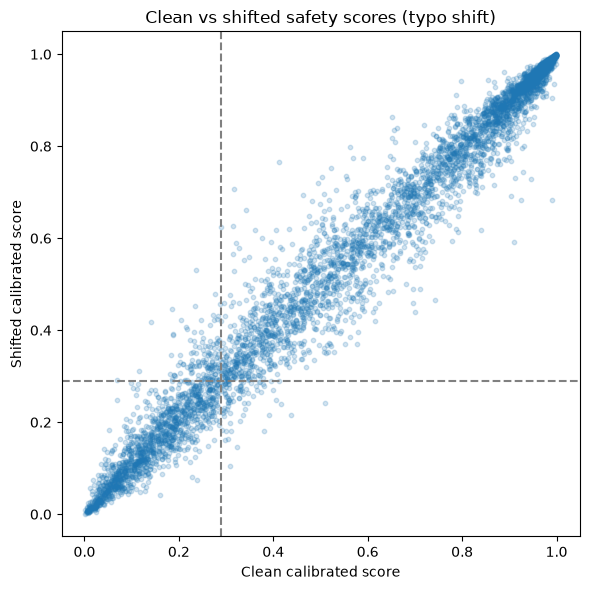

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(p_clean, p_typo, alpha=0.2, s=10)
plt.axhline(threshold, linestyle="--", color="gray")
plt.axvline(threshold, linestyle="--", color="gray")
plt.xlabel("Clean calibrated score")
plt.ylabel("Shifted calibrated score")
plt.title("Clean vs shifted safety scores (typo shift)")
plt.tight_layout()
plt.show()

The lower-right quadrant, above the threshold clean, below it shifted, marks direct decision reversals. Points near the diagonal but off it show erosion that has not yet flipped a decision but is worth tracking.

## 5.13 The threshold does not travel automatically

The threshold is part of the safety policy, not a property of the classifier, and it was selected on one particular validation distribution. "Block above 0.29" is not a complete requirement on its own, the requirement was closer to "on the Chapter 4 calibration distribution, 0.29 achieves our target recall". A shift test asks whether that statement still approximately holds. The robustness table above already answers this for our shifts: recall at the frozen threshold moved from its clean value under each transformation, exactly the quantity the original threshold selection assumed would stay stable.

## 5.14 Base-rate shift revisited

In [13]:
def precision_from_rates(tpr, fpr, prevalence):
    numerator = tpr * prevalence
    denominator = numerator + fpr * (1 - prevalence)
    return numerator / denominator

for prevalence in [0.20, 0.05, 0.01, 0.005]:
    print(prevalence, precision_from_rates(tpr=0.95, fpr=0.03, prevalence=prevalence))

0.2 0.8878504672897196
0.05 0.625
0.01 0.2423469387755102
0.005 0.13728323699421965


No model parameter changed here. Only the population did, yet the meaning of a positive flag changed substantially. Base-rate monitoring belongs in a safety deployment plan for exactly this reason.

## 5.15-5.17 From natural shift to a threat-modelled adversarial shift

Natural shift happens because the world changes. Adversarial shift happens because someone is deliberately searching for inputs that break the system, and unlike natural shift, an adversary adapts: if one transformation fails they try another. Before running anything we should call an "attack", we write down a threat model:

- **Goal**: cause a genuinely unsafe input to be classified as safe.
- **Knowledge**: the attacker knows a text safety classifier exists, not its parameters.
- **Feedback**: the attacker can observe whether a request is blocked.
- **Capabilities**: the attacker can alter surface form while preserving intent.
- **Constraints**: no change to the underlying safety label, the transformation must be meaning-preserving.
- **Budget**: a limited number of attempts per example.

That describes a black-box evasion setting. Writing this down first stops us from treating one arbitrary perturbation as evidence of general adversarial robustness. Our typo shift above is really a stand-in for the simplest member of this family: a small, local, meaning-preserving surface change. A genuine adversarial suite would additionally include manually audited transformations (paraphrase, synonym substitution) where a human has confirmed `semantic_preserved=True` before the example counts towards an evasion metric.

## 5.18 Character n-grams: a more robust representation

A word-level model relies on exact tokens like `"private address"`. A character n-gram model instead learns fragments like `"priv"`, `"riva"`, `"ivate"`, a single typo destroys one word token but leaves most character substrings intact. We select the operating threshold on a validation split carved out of the training data, never on the shifted test sets, then fit the final model on the full training partition.

In [14]:
model_fit_df, model_val_df = train_test_split(
    train_df, test_size=0.20, stratify=train_df["target"], random_state=42,
)
candidate_thresholds = np.linspace(0.05, 0.95, 181)

def select_threshold_on_validation(pipeline_factory):
    val_model = pipeline_factory()
    val_model.fit(model_fit_df["text"], model_fit_df["target"])
    p_val = val_model.predict_proba(model_val_df["text"])[:, 1]
    y_val = model_val_df["target"].to_numpy()
    return recall_constrained_threshold(y_val, p_val, candidate_thresholds, min_recall=0.95)

In [15]:
def make_char_clf():
    return Pipeline([
        ("tfidf_char", TfidfVectorizer(
            analyzer="char_wb", ngram_range=(3, 5), min_df=2,
            max_features=150_000, sublinear_tf=True,
        )),
        ("logreg", LogisticRegression(
            max_iter=1_000, class_weight="balanced", random_state=42,
        )),
    ])

char_threshold = select_threshold_on_validation(make_char_clf)
print("char_threshold:", char_threshold)

char_clf = make_char_clf()
char_clf = char_clf.fit(train_df["text"], train_df["target"])

char_threshold: 0.25999999999999995


We should not assume character n-grams are automatically better. They increase dimensionality and can capture spurious fragments. The point of the rest of the chapter is to actually compare clean and shifted performance rather than assume it.

## 5.19 Compare clean performance and robustness side by side

In [16]:
def evaluate_model_on_df(model, df, threshold_value):
    p = model.predict_proba(df["text"])[:, 1]
    yhat = (p >= threshold_value).astype(int)
    return safety_metrics(df["target"].to_numpy(), yhat)

char_clean = evaluate_model_on_df(char_clf, test_df, char_threshold)
char_typo = evaluate_model_on_df(char_clf, typo_df, char_threshold)

comparison = pd.DataFrame([
    {"model": "word_tfidf", "condition": "clean", **clean_metrics},
    {"model": "word_tfidf", "condition": "typo_shift", **typo_metrics},
    {"model": "char_tfidf", "condition": "clean", **char_clean},
    {"model": "char_tfidf", "condition": "typo_shift", **char_typo},
])
comparison

,model,condition,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn
0,word_tfidf,clean,0.728148,0.922040,0.813703,0.462301,0.077960,2874,1073,1248,243
1,word_tfidf,typo_shift,0.718454,0.924286,0.808475,0.486428,0.075714,2881,1129,1192,236
2,char_tfidf,clean,0.681210,0.946744,0.792321,0.595002,0.053256,2951,1381,940,166
3,char_tfidf,typo_shift,0.671548,0.956368,0.789042,0.628178,0.043632,2981,1458,863,136


The decision is not "pick the model with the highest clean F1". We care about the whole performance surface across conditions, a model that trades a little clean performance for much better shifted recall may be the better safety component even though it loses on the headline benchmark number.

## 5.20 Combine word and character features

In [17]:
from sklearn.pipeline import FeatureUnion

def make_combined_clf():
    word_features = TfidfVectorizer(
        analyzer="word", ngram_range=(1, 2), min_df=2,
        max_features=100_000, sublinear_tf=True,
    )
    char_features = TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3, 5), min_df=2,
        max_features=150_000, sublinear_tf=True,
    )
    return Pipeline([
        ("features", FeatureUnion([("word", word_features), ("char", char_features)])),
        ("logreg", LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=42)),
    ])

combined_threshold = select_threshold_on_validation(make_combined_clf)
print("combined_threshold:", combined_threshold)

combined_clf = make_combined_clf()
combined_clf = combined_clf.fit(train_df["text"], train_df["target"])

combined_threshold: 0.25999999999999995


In [18]:
combined_clean = evaluate_model_on_df(combined_clf, test_df, combined_threshold)
combined_typo = evaluate_model_on_df(combined_clf, typo_df, combined_threshold)
print("combined clean:", combined_clean)
print("combined typo :", combined_typo)

combined clean: {'precision': 0.7072582589823969, 'recall': 0.9409688803336541, 'f1': 0.8075440528634361, 'false_positive_rate': np.float64(0.5230504093063335), 'false_negative_rate': np.float64(0.059031119666345847), 'tp': 2933, 'fp': 1214, 'tn': 1107, 'fn': 184}
combined typo : {'precision': 0.6978281397544853, 'recall': 0.9483477702919474, 'f1': 0.8040255677954576, 'false_positive_rate': np.float64(0.5514864282636794), 'false_negative_rate': np.float64(0.05165222970805262), 'tp': 2956, 'fp': 1280, 'tn': 1041, 'fn': 161}


## 5.21 Build a robustness matrix

With more than one model and more than one shift, a single headline number stops being useful. We also compute worst-case recall and average shifted recall across our predefined shift set, predefined matters, adding shifts until a model loses (or hiding ones that flatter our favourite) is just another form of benchmark manipulation.

In [19]:
robustness_matrix_rows = [
    {"model": "word_tfidf", "condition": "clean", **clean_metrics},
    {"model": "word_tfidf", "condition": "lowercase", **lower_metrics},
    {"model": "word_tfidf", "condition": "remove_punctuation", **punct_metrics},
    {"model": "word_tfidf", "condition": "adjacent_typo_3pct", **typo_metrics},
    {"model": "char_tfidf", "condition": "clean", **char_clean},
    {"model": "char_tfidf", "condition": "adjacent_typo_3pct", **char_typo},
    {"model": "combined", "condition": "clean", **combined_clean},
    {"model": "combined", "condition": "adjacent_typo_3pct", **combined_typo},
]
robustness_matrix = pd.DataFrame(robustness_matrix_rows)
robustness_matrix.to_csv(REPORTS_DIR / "ch5_robustness_matrix.csv", index=False)
robustness_matrix[["model", "condition", "precision", "recall", "f1", "false_positive_rate"]]

,model,condition,precision,recall,f1,false_positive_rate
0,word_tfidf,clean,0.728148,0.922040,0.813703,0.462301
1,word_tfidf,lowercase,0.728148,0.922040,0.813703,0.462301
2,word_tfidf,remove_punctuation,0.725126,0.925890,0.813301,0.471349
3,word_tfidf,adjacent_typo_3pct,0.718454,0.924286,0.808475,0.486428
4,char_tfidf,clean,0.681210,0.946744,0.792321,0.595002
5,char_tfidf,adjacent_typo_3pct,0.671548,0.956368,0.789042,0.628178
6,combined,clean,0.707258,0.940969,0.807544,0.523050
7,combined,adjacent_typo_3pct,0.697828,0.948348,0.804026,0.551486


In [20]:
shifted_conditions = ["lowercase", "remove_punctuation", "adjacent_typo_3pct"]

summary_rows = []
for model_name in robustness_matrix["model"].unique():
    model_rows = robustness_matrix[robustness_matrix["model"] == model_name]
    shifted_rows = model_rows[model_rows["condition"].isin(shifted_conditions)]
    if len(shifted_rows) == 0:
        continue
    summary_rows.append({
        "model": model_name,
        "worst_case_recall": shifted_rows["recall"].min(),
        "average_shifted_recall": shifted_rows["recall"].mean(),
    })

pd.DataFrame(summary_rows)

,model,worst_case_recall,average_shifted_recall
0,word_tfidf,0.922040,0.924072
1,char_tfidf,0.956368,0.956368
2,combined,0.948348,0.948348


## 5.22 Robustness by harm category

An aggregate recall number can hide severe weakness in a rare category. BeaverTails' multilabel harm taxonomy lets us check this directly, remembering that categories are not mutually exclusive, one example can belong to several.

In [21]:
category_df = pd.json_normalize(test_df["category"]).astype(bool)

category_rows = []
for category in category_df.columns:
    mask = category_df[category].to_numpy()
    if mask.sum() == 0:
        continue
    y_cat = y_clean[mask]
    clean_r = recall_score(y_cat, yhat_clean[mask], zero_division=0)
    typo_r = recall_score(y_cat, yhat_typo[mask], zero_division=0)
    category_rows.append({
        "category": category, "n": int(mask.sum()),
        "clean_recall": clean_r, "typo_recall": typo_r, "delta": typo_r - clean_r,
    })

from sklearn.metrics import recall_score
category_robustness = pd.DataFrame(category_rows).sort_values("delta")
category_robustness

,category,n,clean_recall,typo_recall,delta
1,child_abuse,35,0.885714,0.857143,-0.028571
7,"misinformation_regarding_ethics,laws_and_safety",139,0.848921,0.834532,-0.014388
2,"controversial_topics,politics",179,0.703911,0.692737,-0.011173
0,animal_abuse,63,0.984127,0.984127,0.000000
11,"sexually_explicit,adult_content",148,0.885135,0.885135,0.000000
13,"violence,aiding_and_abetting,incitement",1350,0.971111,0.971111,0.000000
6,"hate_speech,offensive_language",533,0.926829,0.928705,0.001876
5,"financial_crime,property_crime,theft",532,0.977444,0.981203,0.003759
4,"drug_abuse,weapons,banned_substance",299,0.969900,0.976589,0.006689
8,non_violent_unethical_behavior,985,0.927919,0.935025,0.007107


Look for heterogeneity rather than one clean average: a model can be robust on categories with distinctive vocabulary and brittle on categories where intent depends heavily on context, and that finding is far more actionable than a single F1 number.

## 5.23-5.24 Data augmentation as a robustness intervention, and its trap

Once we know the word model is weak under typo noise, the obvious intervention is to add typo-shifted training examples. The sequencing matters: freeze the final test shift suite first, augment only training data, retrain, then evaluate on the untouched shifted test set. We must not generate train and test perturbations from the same exact transformed strings and then call the result robustness, that is leakage wearing a different hat.

In [22]:
train_aug = train_df.reset_index(drop=True).copy()
typo_aug = train_df.reset_index(drop=True).sample(frac=0.30, random_state=42).copy()
typo_aug["text"] = typo_aug.apply(typo_shift_row, axis=1)

augmented_train = pd.concat([train_aug, typo_aug], ignore_index=True)
print("augmented_train:", augmented_train.shape, "vs original:", train_df.shape)

augmented_train: (28272, 5) vs original: (21748, 5)


In [23]:
aug_threshold = select_threshold_on_validation(
    lambda: Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True, ngram_range=(1, 2), min_df=2,
            max_features=100_000, sublinear_tf=True,
        )),
        ("logreg", LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=42)),
    ])
)

augmented_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True, ngram_range=(1, 2), min_df=2,
        max_features=100_000, sublinear_tf=True,
    )),
    ("logreg", LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=42)),
])
augmented_clf.fit(augmented_train["text"], augmented_train["target"])

aug_clean = evaluate_model_on_df(augmented_clf, test_df, aug_threshold)
aug_typo = evaluate_model_on_df(augmented_clf, typo_df, aug_threshold)
# A held-out transformation family the augmentation never saw: punctuation removal, standing in
# for "attack B" in the book's terms. This checks generalisation, not memorisation of the exact typo generator.
aug_punct = evaluate_model_on_df(augmented_clf, punct_df, aug_threshold)

augmentation_comparison = pd.DataFrame([
    {"model": "word_tfidf (no augmentation)", "condition": "clean", **clean_metrics},
    {"model": "word_tfidf (no augmentation)", "condition": "typo_shift", **typo_metrics},
    {"model": "word_tfidf (no augmentation)", "condition": "remove_punctuation", **punct_metrics},
    {"model": "word_tfidf (typo-augmented)", "condition": "clean", **aug_clean},
    {"model": "word_tfidf (typo-augmented)", "condition": "typo_shift", **aug_typo},
    {"model": "word_tfidf (typo-augmented)", "condition": "remove_punctuation", **aug_punct},
])
augmentation_comparison[["model", "condition", "precision", "recall", "f1"]]

,model,condition,precision,recall,f1
0,word_tfidf (no augmentation),clean,0.728148,0.922040,0.813703
1,word_tfidf (no augmentation),typo_shift,0.718454,0.924286,0.808475
2,word_tfidf (no augmentation),remove_punctuation,0.725126,0.925890,0.813301
3,word_tfidf (typo-augmented),clean,0.709038,0.941290,0.808822
4,word_tfidf (typo-augmented),typo_shift,0.695928,0.948669,0.802878
5,word_tfidf (typo-augmented),remove_punctuation,0.706490,0.942894,0.807750


If typo recall improved substantially while clean performance held up, the intervention looks promising, that is a trade-off to measure, not assume. More importantly: did recall on `remove_punctuation`, a transformation the augmentation never trained on, also improve? If augmentation only helps on the exact perturbation it was trained on, we have learned that the model memorised attack A, not that it became more robust. Generalisation to an unseen transformation family is the stronger and more honest claim.

## 5.25 Distribution shift can break calibration

Chapter 4 separated discrimination from calibration. Under shift, a model can keep much of its ranking ability while becoming badly overconfident or underconfident, we check this without refitting the calibrator, we are measuring whether the existing calibration transfers, not building a new one.

In [24]:
from sklearn.metrics import brier_score_loss

brier_clean = brier_score_loss(y_clean, p_clean)
brier_typo = brier_score_loss(y_clean, p_typo)
print("Brier (clean):", brier_clean)
print("Brier (typo) :", brier_typo)

Brier (clean): 0.14242556054504774
Brier (typo) : 0.14568632739664858


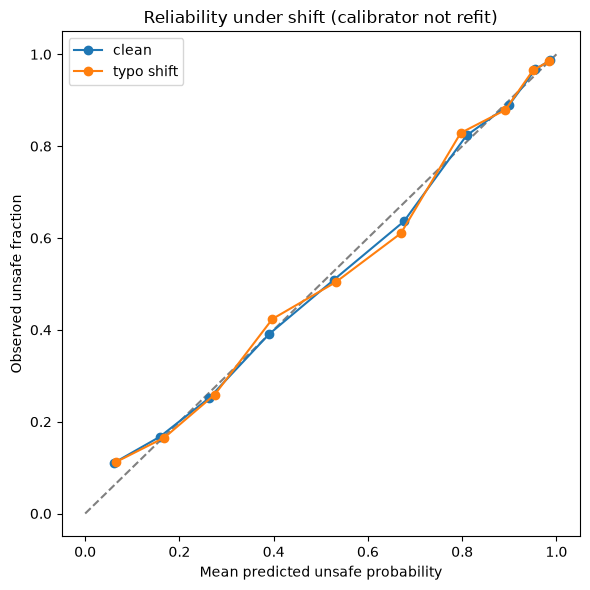

In [25]:
from sklearn.calibration import calibration_curve

frac_pos_clean, mean_pred_clean = calibration_curve(y_clean, p_clean, n_bins=10, strategy="quantile")
frac_pos_typo, mean_pred_typo = calibration_curve(y_clean, p_typo, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.plot(mean_pred_clean, frac_pos_clean, marker="o", label="clean")
plt.plot(mean_pred_typo, frac_pos_typo, marker="o", label="typo shift")
plt.xlabel("Mean predicted unsafe probability")
plt.ylabel("Observed unsafe fraction")
plt.title("Reliability under shift (calibrator not refit)")
plt.legend()
plt.tight_layout()
plt.show()

## 5.26 Population Stability Index

In production, labels often arrive slowly or not at all, so we need drift indicators that work on inputs or scores alone. PSI compares the proportion of a reference and a current distribution falling into the same bins.

In [26]:
bins = np.quantile(p_clean, np.linspace(0, 1, 11))
bins[0], bins[-1] = -np.inf, np.inf

def psi(reference, current, bins, eps=1e-6):
    ref_counts, _ = np.histogram(reference, bins=bins)
    cur_counts, _ = np.histogram(current, bins=bins)
    p = np.clip(ref_counts / ref_counts.sum(), eps, None)
    q = np.clip(cur_counts / cur_counts.sum(), eps, None)
    return np.sum((q - p) * np.log(q / p))

score_psi = psi(p_clean, p_typo, bins)
print("PSI (clean vs typo scores):", score_psi)

PSI (clean vs typo scores): 0.0036332026906209657


PSI is easy to explain and widely used, but it is not a magic threshold detector, its value depends on binning and sample size. Treat it as a signal to investigate, not proof that the system has become unsafe.

## 5.27-5.28 KL and Jensen-Shannon divergence

In [27]:
from scipy.spatial.distance import jensenshannon

ref_counts, _ = np.histogram(p_clean, bins=bins)
cur_counts, _ = np.histogram(p_typo, bins=bins)
ref_probs = ref_counts / ref_counts.sum()
cur_probs = cur_counts / cur_counts.sum()

# jensenshannon returns a distance (sqrt of the divergence) by default
js_distance = jensenshannon(ref_probs, cur_probs, base=2)
print("Jensen-Shannon distance (clean vs typo scores):", js_distance)

Jensen-Shannon distance (clean vs typo scores): 0.025593232086525957


KL divergence is asymmetric and blows up when the reference assigns zero probability somewhere the current distribution does not, which is why finite empirical distributions need smoothing. Jensen-Shannon divergence fixes both problems by comparing each distribution against their mixture and is symmetric by construction. Both are only as meaningful as the distribution you chose to bin, here, the calibrated score, a coarse but interpretable summary of a very high-dimensional text distribution.

## 5.29 Drift in model scores can be more actionable than drift in raw text

Raw language is hard to monitor directly, the feature space is enormous. The score compresses everything into one number tied directly to the decision policy.

In [28]:
def score_monitoring_summary(scores, threshold_value, review_low=None, review_high=None):
    summary = {
        "mean_score": float(np.mean(scores)),
        "median_score": float(np.median(scores)),
        "p95_score": float(np.quantile(scores, 0.95)),
        "pct_above_block": float(np.mean(scores >= threshold_value)),
    }
    if review_low is not None and review_high is not None:
        summary["pct_in_review_band"] = float(np.mean((scores >= review_low) & (scores < review_high)))
    return summary

print("clean :", score_monitoring_summary(p_clean, threshold))
print("typo  :", score_monitoring_summary(p_typo, threshold))

clean : {'mean_score': 0.5727267783109096, 'median_score': 0.5965032806589112, 'p95_score': 0.9867125103868581, 'pct_above_block': 0.7258183155571901}
typo  : {'mean_score': 0.5730490247814309, 'median_score': 0.5977169016708495, 'p95_score': 0.9851507822015569, 'pct_above_block': 0.7374034571533652}


If the production score distribution moves substantially towards the block threshold, review volume can rise before any ground-truth performance measurement is even possible. But score stability does not guarantee input stability, an adversarial population could shift while the score distribution looks superficially unchanged. Production monitoring needs more than one layer.

## 5.30 A simple feature-space distance

In [29]:
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = base_clf.named_steps["tfidf"]

X_ref = vectorizer.transform(train_df["text"].sample(n=min(10_000, len(train_df)), random_state=42))
centroid = np.asarray(X_ref.mean(axis=0))

# Reference familiarity: how similar does *normal* (clean) test traffic look to the training centroid?
# Cosine similarity to a single mean vector of sparse TF-IDF vectors is naturally low even for typical
# in-distribution text, so "familiar" only makes sense relative to this reference, not an absolute cutoff.
similarity_clean = cosine_similarity(vectorizer.transform(test_df["text"]), centroid).ravel()
similarity_typo = cosine_similarity(vectorizer.transform(typo_df["text"]), centroid).ravel()

print("clean similarity:", pd.Series(similarity_clean).describe(percentiles=[0.05, 0.5, 0.95]).to_dict())
print("typo similarity :", pd.Series(similarity_typo).describe(percentiles=[0.05, 0.5, 0.95]).to_dict())

clean similarity: {'count': 5438.0, 'mean': 0.13204442636669073, 'std': 0.03367108286210698, 'min': 0.02563454540086194, '5%': 0.0756603608825727, '50%': 0.1324999111461802, '95%': 0.18708180518798173, 'max': 0.2386011916128551}
typo similarity : {'count': 5438.0, 'mean': 0.13441235424872872, 'std': 0.03482650021785252, 'min': 0.0211591432721454, '5%': 0.07614006311614219, '50%': 0.13580024702481325, '95%': 0.19089449872013214, 'max': 0.25246691450159736}


Similarity is a crude unfamiliarity signal, not a calibrated probability of being out of distribution, a single centroid barely summarises a multimodal language distribution. It is still pedagogically useful: the classifier tells us what it predicts, this tells us how familiar the input's representation looks, and those are different questions. What counts as "low" only makes sense relative to a reference period of normal traffic, which is what we use below.

## 5.31 Abstention when the input looks unfamiliar

We extend Chapter 4's allow/review/block policy with a familiarity signal, an example is flagged as unusually unfamiliar if its similarity falls below the 5th percentile of the *clean reference* distribution above. An extremely unfamiliar input can be routed for review even if its unsafe score is low, low confidence and unfamiliarity are not the same thing.

In [30]:
familiarity_floor = float(np.quantile(similarity_clean, 0.05))
print("Familiarity floor (5th percentile of reference similarity):", familiarity_floor)

def safety_action_with_unfamiliarity(p_unsafe, sim, block_at, review_at=0.25, familiar_min=familiarity_floor):
    if sim < familiar_min:
        return "review"  # unusually unfamiliar relative to reference traffic, escalate regardless of score
    if p_unsafe < review_at:
        return "allow"
    if p_unsafe < block_at:
        return "review"
    return "block"

actions = [
    safety_action_with_unfamiliarity(p, s, block_at=threshold)
    for p, s in zip(p_typo, similarity_typo)
]
print(pd.Series(actions).value_counts(normalize=True))

Familiarity floor (5th percentile of reference similarity): 0.0756603608825727
block     0.698602
allow     0.221221
review    0.080177
Name: proportion, dtype: float64


This will increase review volume, and that cost has to be measured against capacity, exactly as in Chapter 4. If a large fraction of legitimate traffic gets flagged as unfamiliar, the unfamiliarity detector is not helping operationally, it is just adding friction.

## 5.32-5.34 Diagnosing drift, performance drift, and policy drift

A PSI spike tells us the distribution moved, not why. Possible explanations range from a legitimate new user population to a coordinated attack to a broken monitoring pipeline itself, drift alerts need diagnostic dimensions (model version, language, request source, category) to be investigable rather than merely alarming.

Input drift and score drift need no ground truth. **Performance drift does**: to know false negatives increased, we need labels, which in safety systems are often expensive, delayed or selectively observed. A practical strategy combines continuous unlabeled drift monitoring, random sampling for annotation, oversampling of borderline/blocked examples for diagnosis, incident-triggered retrospective labelling, and periodic benchmark refreshes. The sampling design has to match the metric you want, labelling only blocked examples can never reveal false negatives among allowed traffic.

**Policy drift** is a third, separate thing: the model and input distribution can stay identical while the organisation changes what action a given score should trigger. That is concept drift from the label's point of view, but it needs explicit versioning of its own, model version, vectoriser version, calibrator version, policy version, threshold version and reference dataset version should all be recorded together, because a safety incident cannot be reconstructed from the model version alone.

## 5.35-5.36 External challenge sets and dataset mapping

Every shift so far is still a transformation of BeaverTails itself, useful for isolating one specific change, but it never leaves the BeaverTails dataset family. A stronger test evaluates on an independently constructed safety dataset with a different collection and annotation process. One option is [WildGuardMix](https://huggingface.co/datasets/allenai/wildguardmix) (AI2), which mixes benign/harmful, vanilla/adversarial and prompt-only/prompt-response examples. Access requires accepting AI2's Responsible Use Guidelines, so it is intentionally not a hard dependency of this notebook.

External evaluation is not just a matter of running the same classifier and comparing scores. Different datasets do not necessarily define "unsafe" the same way, if one dataset labels the prompt-response pair jointly and another separates `prompt_harmfulness` from `response_harmfulness`, the mapping between the two has to be written down explicitly (for example, `external_df["target"] = (external_df["response_harmfulness"] == "harmful").astype(int)` if this classifier is meant to judge response harmfulness). A lower external score can reflect genuine model weakness, a label-policy mismatch, or both, which is exactly why external validation is valuable: it forces those assumptions into the open.

## 5.37 A robustness report should separate four questions

1. **Clean generalisation**: performance on held-out data from the same benchmark family used in development.
2. **Natural robustness**: behaviour under plausible non-adversarial change, formatting, typos, population shifts.
3. **Adversarial robustness**: how often a meaning-preserving transformation reverses a decision under a defined threat model.
4. **External generalisation**: performance on an independently constructed safety dataset.

These should not collapse into one "robustness score" unless the aggregation rule is fully documented, a model can be excellent at one and weak at another.

## 5.38 A reproducible shift registry

In [31]:
shift_registry = {
    "shifts": {
        "lowercase_v1": {
            "family": "natural", "semantic_preservation": "assumed",
            "implementation": "lower_case",
        },
        "punctuation_remove_v1": {
            "family": "natural", "semantic_preservation": "sampled_review",
            "implementation": "remove_punctuation",
        },
        "adjacent_typo_3pct_v1": {
            "family": "natural", "semantic_preservation": "sampled_review",
            "implementation": "swap_adjacent_chars",
            "parameters": {"p": 0.03, "seed": 42},
        },
    }
}

with open(CONFIG_DIR / "ch5_shift_registry.yaml", "w") as f:
    yaml.safe_dump(shift_registry, f, sort_keys=False)

print((CONFIG_DIR / "ch5_shift_registry.yaml").read_text())

shifts:
  lowercase_v1:
    family: natural
    semantic_preservation: assumed
    implementation: lower_case
  punctuation_remove_v1:
    family: natural
    semantic_preservation: sampled_review
    implementation: remove_punctuation
  adjacent_typo_3pct_v1:
    family: natural
    semantic_preservation: sampled_review
    implementation: swap_adjacent_chars
    parameters:
      p: 0.03
      seed: 42



This looks like over-engineering with only three transformations. By the time a real suite has twenty attack families, several model versions and multiple safety policies, a versioned registry like this is what keeps a robustness result reproducible and interpretable months later.

## 5.39-5.40 Monitoring reference windows and alerting discipline

A drift metric compares the current period to a reference, and which reference is itself a design choice. A fixed reference (the validation data used at deployment approval) gives a stable baseline that can go stale. A rolling reference (this week vs. the last four) adapts to gradual change but can quietly normalise slow deterioration; six months of small weekly moves can add up to a large total drift that no single week-over-week comparison ever flags. A useful compromise keeps both: a fixed approval reference and a recent operational reference, and reports drift against each.

A monitoring system that alerts on every wiggle gets ignored. Rather than one arbitrary PSI cutoff, an alert should weigh minimum sample size, persistence across multiple windows, magnitude of movement, whether the score distribution and decision rates moved together, concentration in a high-risk category, and whether a deployment or upstream change happened at the same time, for example: unusual input drift alone triggers investigation, input drift plus score drift triggers increased sampling, and labelled performance degradation triggers a mitigation or rollback review. The drift statistic should drive an operational response, not decorate a dashboard.

## 5.41 Practical exercise: break the classifier you built

The goal here is not to maximise a score, it is to find where the safety evidence stops generalising. Using the pieces already built above:

1. Compare all four conditions (clean, lowercase-or-punctuation, typo, and one manually audited meaning-preserving challenge transformation of your own) across precision, recall, F1, false-positive rate, false-negative rate, mean calibrated score, Brier score, and absolute degradation in recall and precision.
2. Compute the evasion success rate for your own challenge transformation among unsafe examples the clean model originally detected.
3. Extend `robustness_matrix` with your challenge transformation for all three model families (word, char, combined), still choosing thresholds only on `model_val_df`, never on any shifted test set.

Then answer: which shift causes the largest operational degradation? Which errors are genuinely caused by distribution shift rather than an ambiguous label? Does the model with the best clean F1 also have the best worst-case recall? Does character information improve robustness without pushing false positives to an unacceptable level? Which shift would you add to training data, and which would you keep hidden as a permanent final challenge set? What production signal would tell you this kind of shift is happening for real? If you have WildGuardMix access, treat it as a separate, optional final question, cross-dataset generalisation is a different claim from controlled-transformation robustness, and the two results should never be merged into one number.

## Where we've arrived

Chapter 4 gave us a safety operating point. This chapter asked whether that operating point survives when the data moves, and the honest answer, visible in the tables above, is: partially, and unevenly across shifts and harm categories.

We made the IID assumption explicit, separated covariate shift, label shift and concept drift, and built traceable, label-preserving shifted test sets rather than corrupting training data directly. Pairwise analysis showed which examples crossed the decision boundary, and score-level analysis showed that degradation begins well before a hard prediction flips. We threat-modelled adversarial shift instead of treating "attack" as a single undefined category, then built character n-gram and combined representations specifically to test whether a different feature space preserves more signal under lexical corruption, comparing them on a full robustness matrix rather than one clean F1 number. Data augmentation showed both its promise and its trap: it only counts as robustness if it generalises to a transformation it never trained on. Finally, PSI, Jensen-Shannon distance, and feature-space similarity gave us ways to detect movement in production before any label is available, feeding an extended allow/review/block policy and a monitoring discipline that separates input drift, score drift, performance drift and policy drift.

So far, the safety mechanism itself has been the thing under attack. **Chapter 6** moves the target: from classifier robustness to red-teaming and jailbreak evaluation of the language model the guardrail is meant to constrain.